# 📊 01 — Exploratory Data Analysis
**Dataset:** Impact of AI on Students  
**Goal:** Understand the distribution, relationships, and quirks of the data before any modelling.

---
## Table of Contents
1. [Setup & Data Loading](#1-setup--data-loading)
2. [Basic Info](#2-basic-info)
3. [Missing Values](#3-missing-values)
4. [Statistical Summary](#4-statistical-summary)
5. [Target Variable Analysis](#5-target-variable-analysis)
6. [Numerical Feature Distributions](#6-numerical-feature-distributions)
7. [Categorical Feature Analysis](#7-categorical-feature-analysis)
8. [Correlation & Heatmap](#8-correlation--heatmap)
9. [Bivariate Analysis — Features vs Targets](#9-bivariate-analysis)
10. [Outlier Detection](#10-outlier-detection)
11. [Key Insights](#11-key-insights)


## 1. Setup & Data Loading

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                      "axes.spines.right": False})

FIGURES = Path("../reports/figures")
FIGURES.mkdir(parents=True, exist_ok=True)

def save(name):
    plt.savefig(FIGURES / name, bbox_inches="tight", dpi=150)
    plt.show()

print("Libraries loaded ✓")

Libraries loaded ✓


In [2]:
RAW = Path("../Data/raw/ai_student_impact_dataset (1).csv")
df = pd.read_csv(RAW)
print(f"Shape: {df.shape}")
df.head()

Shape: (50000, 16)


,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


## 2. Basic Info

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

In [4]:
print("Column types breakdown:")
print(df.dtypes.value_counts())
print()
print("Unique values per column:")
df.nunique().rename("unique_count").to_frame()

Column types breakdown:
object     6
float64    5
int64      4
bool       1
Name: count, dtype: int64

Unique values per column:


,unique_count
Student_ID,50000
Major_Category,5
Year_of_Study,5
Pre_Semester_GPA,2389
Weekly_GenAI_Hours,3566
Primary_Use_Case,5
Prompt_Engineering_Skill,3
Tool_Diversity,5
Paid_Subscription,2
Traditional_Study_Hours,2516


## 3. Missing Values
> This dataset is **complete** — no nulls — but we still visualise for confirmation.

In [5]:
missing = df.isnull().sum()
print("Total missing values:", missing.sum())
missing[missing > 0] if missing.sum() > 0 else print("✅ No missing values detected!")

Total missing values: 0
✅ No missing values detected!


## 4. Statistical Summary

In [6]:
df.describe(include="all").T.style.background_gradient(axis=0, cmap="Blues")

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Student_ID,50000.000000,nan,nan,nan,125000.500000,14433.901067,100001.000000,112500.750000,125000.500000,137500.250000,150000.000000
Major_Category,50000,5,STEM,15059,nan,nan,nan,nan,nan,nan,nan
Year_of_Study,50000,5,Junior,11045,nan,nan,nan,nan,nan,nan,nan
Pre_Semester_GPA,50000.000000,nan,nan,nan,3.146102,0.478854,1.183000,2.834000,3.210000,3.521000,3.998000
Weekly_GenAI_Hours,50000.000000,nan,nan,nan,8.427752,8.269490,0.000000,2.390000,5.800000,11.720000,40.000000
Primary_Use_Case,50000,5,Debugging/Troubleshooting,12295,nan,nan,nan,nan,nan,nan,nan
Prompt_Engineering_Skill,50000,3,Beginner,18495,nan,nan,nan,nan,nan,nan,nan
Tool_Diversity,50000.000000,nan,nan,nan,2.800260,1.188020,1.000000,2.000000,3.000000,4.000000,5.000000
Paid_Subscription,50000,2,False,28846,nan,nan,nan,nan,nan,nan,nan
Traditional_Study_Hours,50000.000000,nan,nan,nan,11.209271,5.156426,1.000000,7.560000,11.180000,14.710000,35.860000


## 5. Target Variable Analysis
We have **two modelling tasks**:
- 🎯 **Regression** → `Post_Semester_GPA`
- 🎯 **Classification** → `Burnout_Risk_Level`

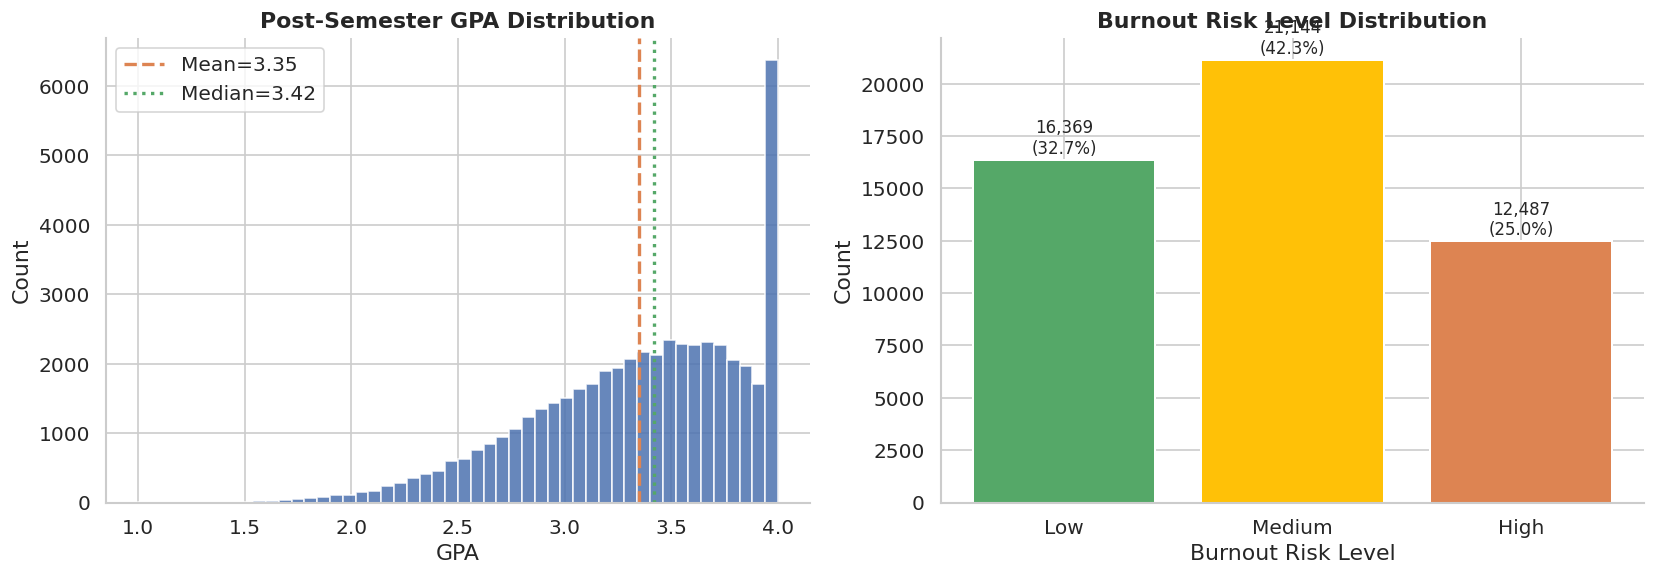

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Post_Semester_GPA — histogram
axes[0].hist(df["Post_Semester_GPA"], bins=50, color="#4C72B0", edgecolor="white", alpha=0.85)
axes[0].axvline(df["Post_Semester_GPA"].mean(), color="#DD8452", linestyle="--", lw=2, label=f'Mean={df["Post_Semester_GPA"].mean():.2f}')
axes[0].axvline(df["Post_Semester_GPA"].median(), color="#55A868", linestyle=":", lw=2, label=f'Median={df["Post_Semester_GPA"].median():.2f}')
axes[0].set_title("Post-Semester GPA Distribution", fontweight="bold")
axes[0].set_xlabel("GPA")
axes[0].set_ylabel("Count")
axes[0].legend()

# Burnout_Risk_Level — bar chart
order = ["Low", "Medium", "High"]
counts = df["Burnout_Risk_Level"].value_counts().reindex(order)
colors = ["#55A868", "#FFC107", "#DD8452"]
bars = axes[1].bar(order, counts.values, color=colors, edgecolor="white", linewidth=1.2)
for bar, count in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f"{count:,}\n({count/len(df)*100:.1f}%)", ha="center", va="bottom", fontsize=10)
axes[1].set_title("Burnout Risk Level Distribution", fontweight="bold")
axes[1].set_xlabel("Burnout Risk Level")
axes[1].set_ylabel("Count")

plt.tight_layout()
save("01_target_distributions.png")

In [8]:
print("Post_Semester_GPA stats:")
print(df["Post_Semester_GPA"].describe().round(3))
print()
print("Burnout_Risk_Level counts:")
print(df["Burnout_Risk_Level"].value_counts())
print()
skew = df["Post_Semester_GPA"].skew()
print(f"GPA Skewness: {skew:.4f} ({'fairly symmetric' if abs(skew) < 0.5 else 'skewed'})")

Post_Semester_GPA stats:
count    50000.000
mean         3.349
std          0.496
min          1.000
25%          3.024
50%          3.421
75%          3.749
max          4.000
Name: Post_Semester_GPA, dtype: float64

Burnout_Risk_Level counts:
Burnout_Risk_Level
Medium    21144
Low       16369
High      12487
Name: count, dtype: int64

GPA Skewness: -0.6751 (skewed)


## 6. Numerical Feature Distributions

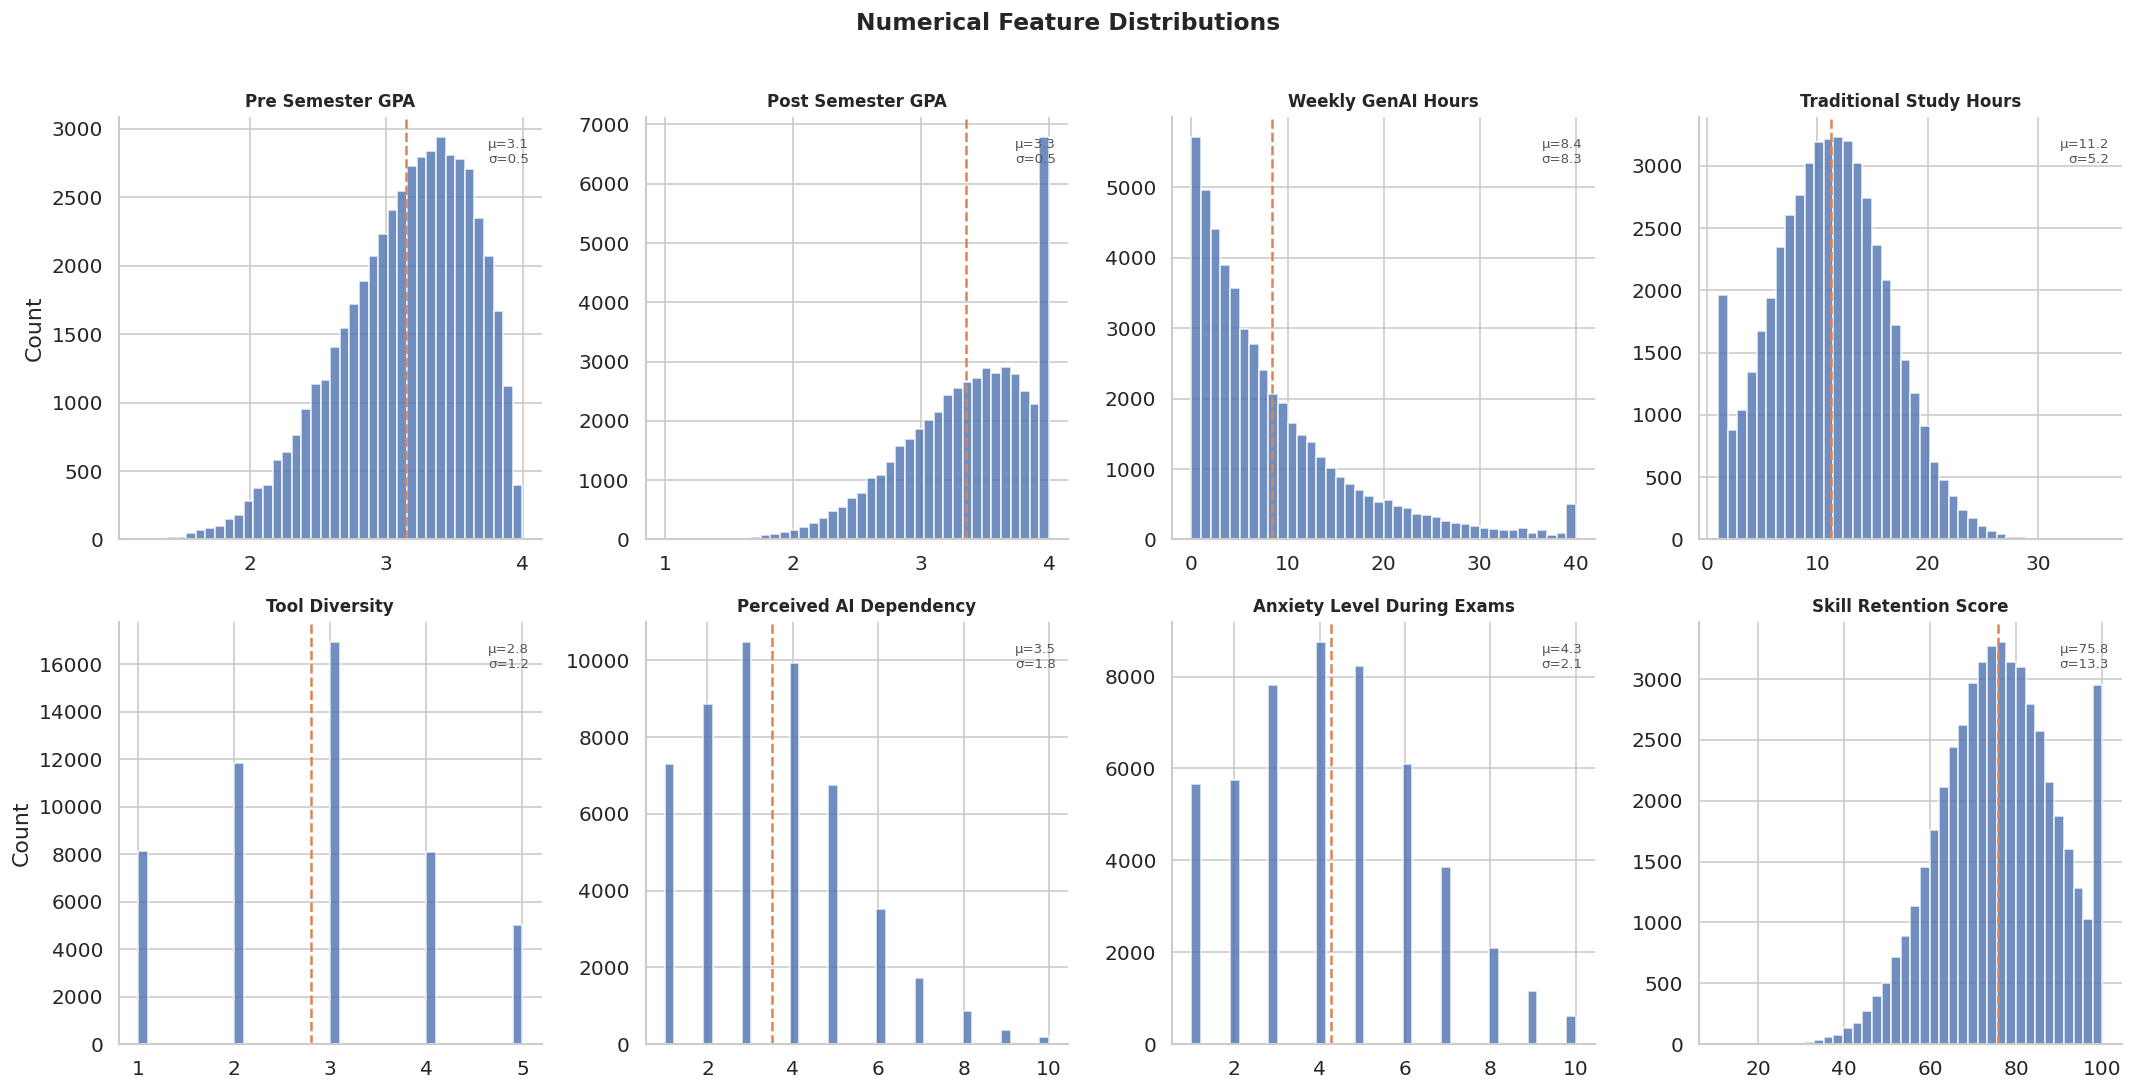

In [9]:
num_cols = ["Pre_Semester_GPA", "Post_Semester_GPA", "Weekly_GenAI_Hours",
            "Traditional_Study_Hours", "Tool_Diversity", "Perceived_AI_Dependency",
            "Anxiety_Level_During_Exams", "Skill_Retention_Score"]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    data = df[col]
    ax.hist(data, bins=40, color="#4C72B0", edgecolor="white", alpha=0.8)
    ax.axvline(data.mean(), color="#DD8452", linestyle="--", lw=1.5)
    ax.set_title(col.replace("_", " "), fontsize=10, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Count" if ax in axes[::4] else "")
    ax.text(0.97, 0.95, f"μ={data.mean():.1f}\nσ={data.std():.1f}", transform=ax.transAxes,
            ha="right", va="top", fontsize=8, color="#555555")

plt.suptitle("Numerical Feature Distributions", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
save("02_numerical_distributions.png")

Average GPA change: +0.2032
Students who improved: 43,759 (87.5%)
Students who declined: 6,192 (12.4%)


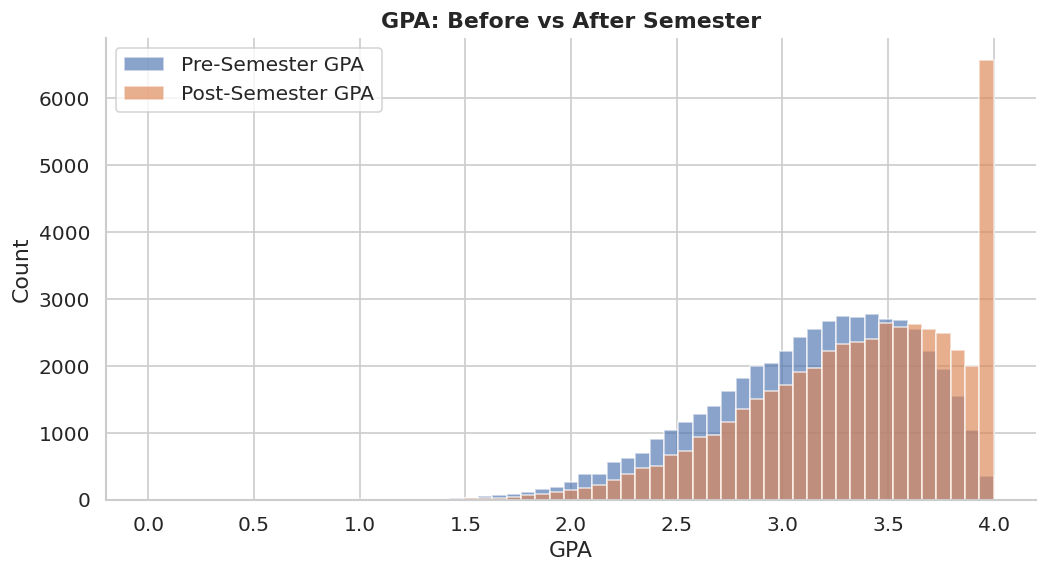

In [10]:
# GPA comparison: before vs after semester
fig, ax = plt.subplots(figsize=(10, 5))
bins = np.linspace(0, 4, 60)
ax.hist(df["Pre_Semester_GPA"], bins=bins, alpha=0.65, color="#4C72B0", label="Pre-Semester GPA", edgecolor="white")
ax.hist(df["Post_Semester_GPA"], bins=bins, alpha=0.65, color="#DD8452", label="Post-Semester GPA", edgecolor="white")
ax.set_title("GPA: Before vs After Semester", fontweight="bold")
ax.set_xlabel("GPA")
ax.set_ylabel("Count")
ax.legend()

gpa_diff = df["Post_Semester_GPA"] - df["Pre_Semester_GPA"]
print(f"Average GPA change: {gpa_diff.mean():+.4f}")
print(f"Students who improved: {(gpa_diff > 0).sum():,} ({(gpa_diff > 0).mean()*100:.1f}%)")
print(f"Students who declined: {(gpa_diff < 0).sum():,} ({(gpa_diff < 0).mean()*100:.1f}%)")
save("03_gpa_comparison.png")

## 7. Categorical Feature Analysis

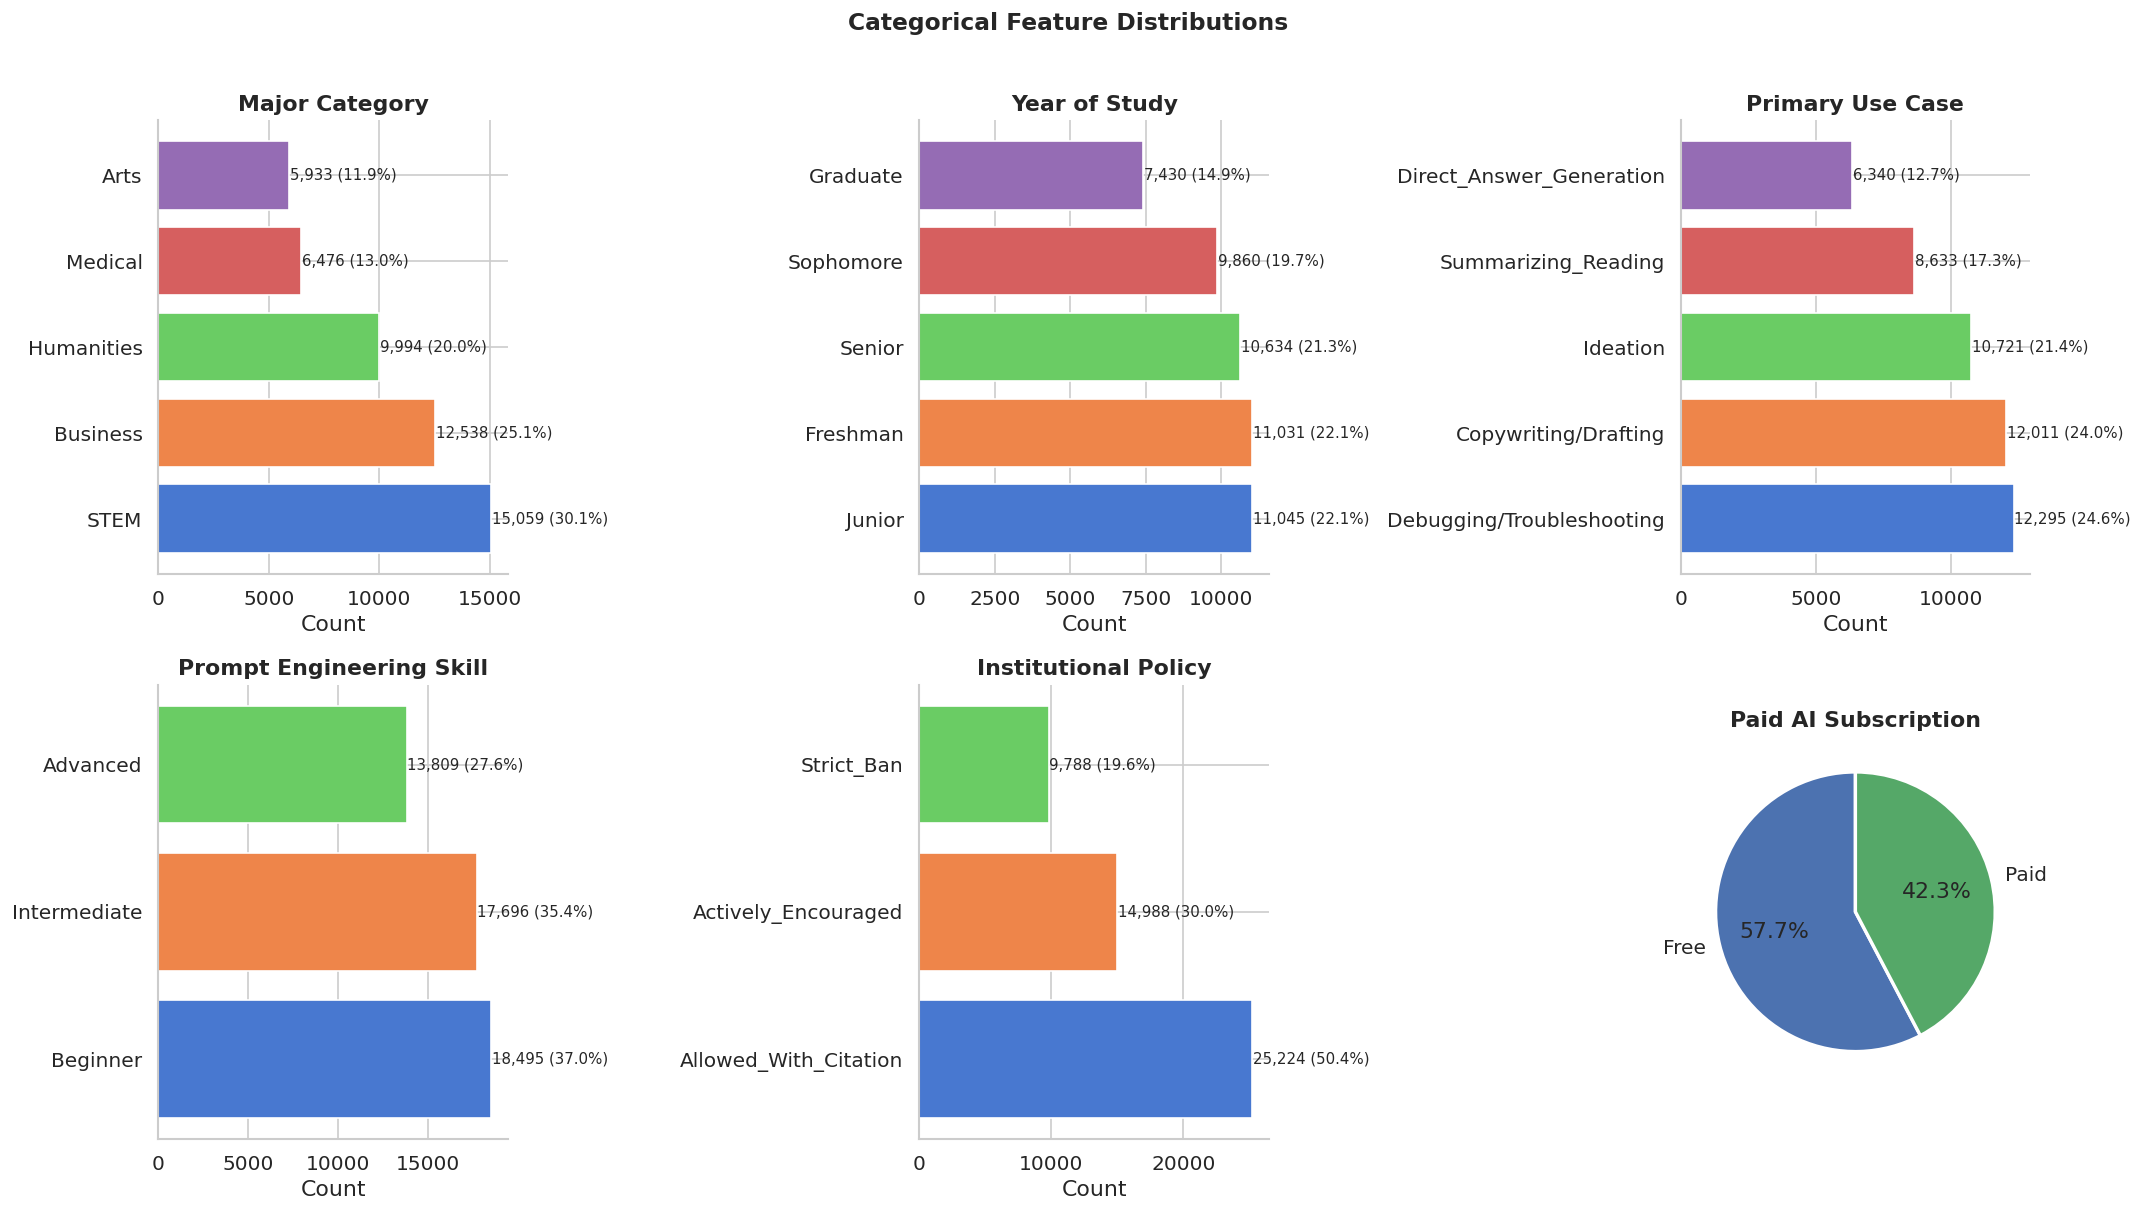

In [11]:
cat_cols = ["Major_Category", "Year_of_Study", "Primary_Use_Case",
            "Prompt_Engineering_Skill", "Institutional_Policy"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
palette = sns.color_palette("muted", 8)

for ax, col in zip(axes, cat_cols):
    counts = df[col].value_counts()
    bars = ax.barh(counts.index, counts.values, color=palette[:len(counts)], edgecolor="white")
    for bar, val in zip(bars, counts.values):
        ax.text(val + 30, bar.get_y() + bar.get_height()/2,
                f"{val:,} ({val/len(df)*100:.1f}%)", va="center", fontsize=9)
    ax.set_title(col.replace("_", " "), fontweight="bold")
    ax.set_xlabel("Count")

# Paid subscription pie
paid_counts = df["Paid_Subscription"].value_counts()
axes[5].pie(paid_counts.values, labels=["Free", "Paid"],
            autopct="%1.1f%%", colors=["#4C72B0", "#55A868"],
            startangle=90, wedgeprops=dict(edgecolor="white", linewidth=2))
axes[5].set_title("Paid AI Subscription", fontweight="bold")

plt.suptitle("Categorical Feature Distributions", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
save("04_categorical_distributions.png")

## 8. Correlation & Heatmap

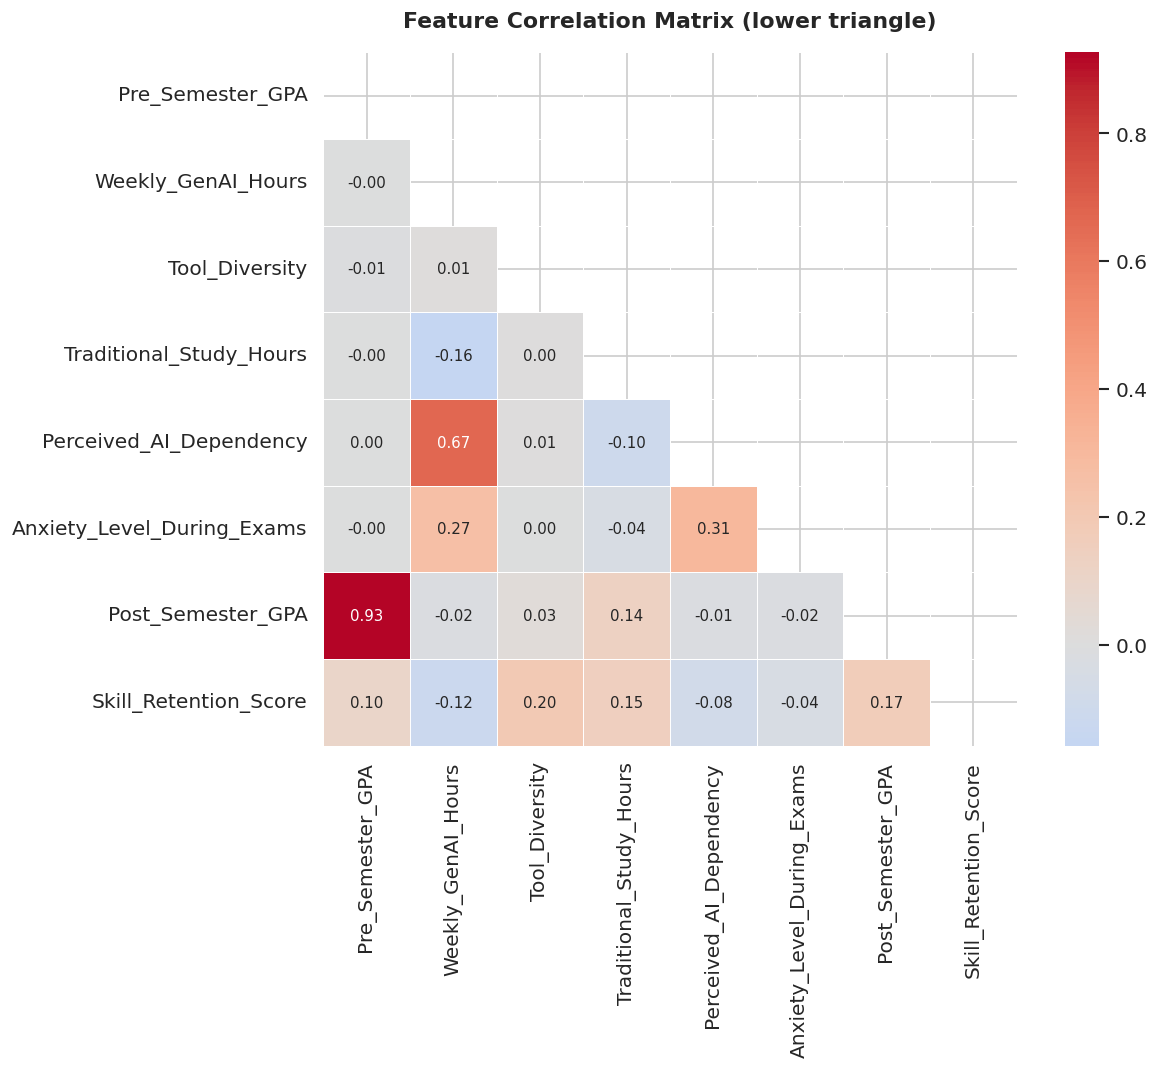

In [12]:
num_df = df.select_dtypes(include="number").drop(columns=["Student_ID"])

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(num_df.corr(), dtype=bool))
sns.heatmap(
    num_df.corr(),
    mask=mask,
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    linewidths=0.5, linecolor="white",
    ax=ax, square=True,
    annot_kws={"size": 9}
)
ax.set_title("Feature Correlation Matrix (lower triangle)", fontweight="bold", pad=15)
plt.tight_layout()
save("05_correlation_heatmap.png")

In [13]:
# Top correlations with Post_Semester_GPA
corr_with_gpa = num_df.corr()["Post_Semester_GPA"].drop("Post_Semester_GPA").sort_values(key=abs, ascending=False)
print("Top correlations with Post_Semester_GPA:")
print(corr_with_gpa.round(4).to_string())

Top correlations with Post_Semester_GPA:
Pre_Semester_GPA              0.9268
Skill_Retention_Score         0.1696
Traditional_Study_Hours       0.1377
Tool_Diversity                0.0253
Weekly_GenAI_Hours           -0.0186
Anxiety_Level_During_Exams   -0.0159
Perceived_AI_Dependency      -0.0142


## 9. Bivariate Analysis — Features vs Targets

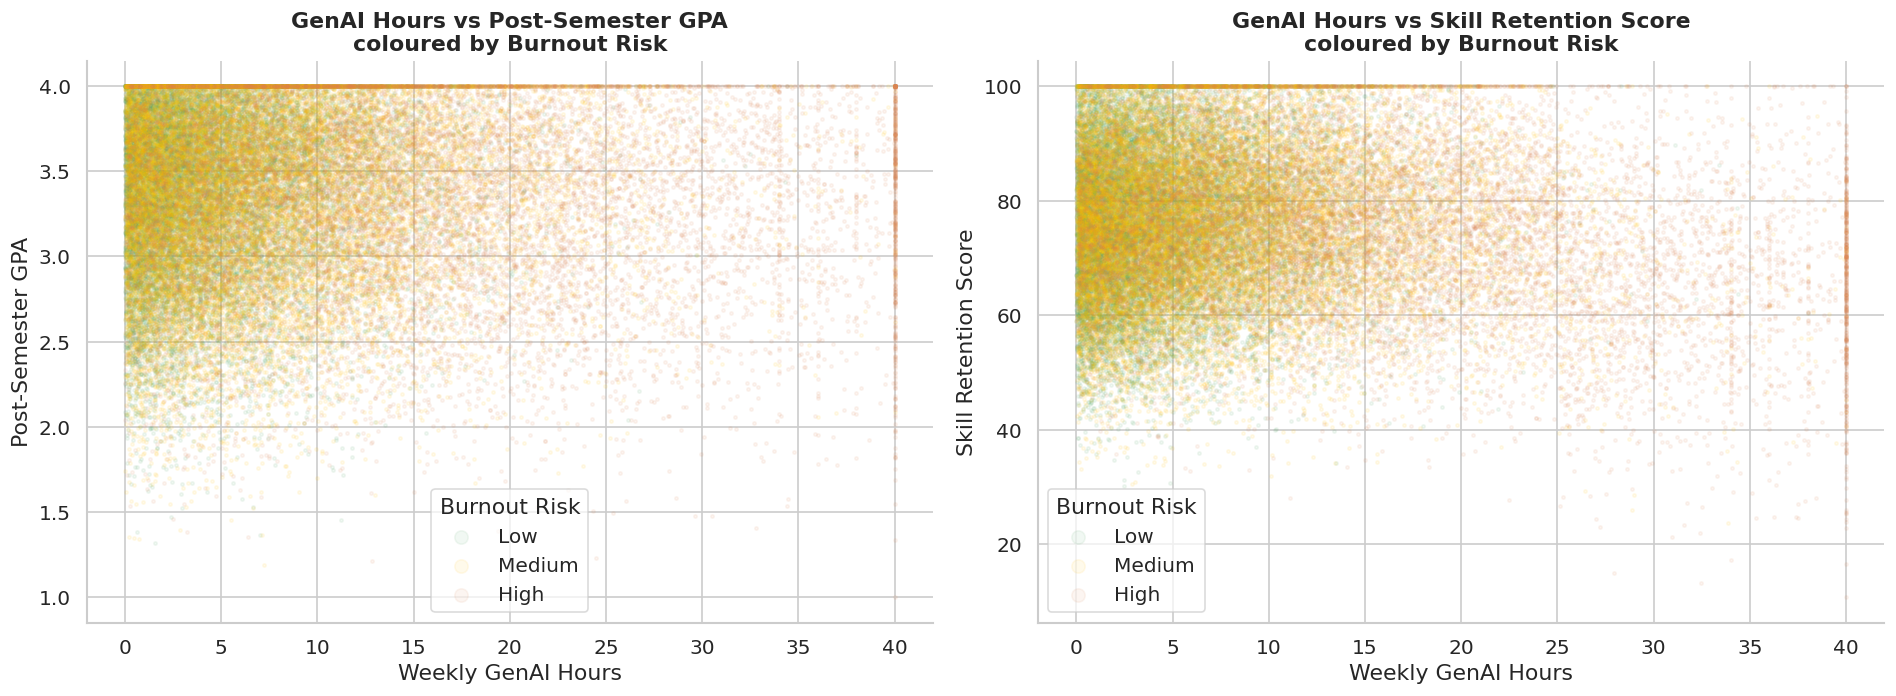

In [14]:
# GenAI hours vs GPA coloured by Burnout
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

burnout_palette = {"Low": "#55A868", "Medium": "#FFC107", "High": "#DD8452"}

for ax, y_col, title in zip(
    axes,
    ["Post_Semester_GPA", "Skill_Retention_Score"],
    ["Post-Semester GPA", "Skill Retention Score"]
):
    for level, color in burnout_palette.items():
        sub = df[df["Burnout_Risk_Level"] == level]
        ax.scatter(sub["Weekly_GenAI_Hours"], sub[y_col], alpha=0.08, s=4,
                   color=color, label=level)
    ax.set_xlabel("Weekly GenAI Hours")
    ax.set_ylabel(title)
    ax.set_title(f"GenAI Hours vs {title}\ncoloured by Burnout Risk", fontweight="bold")
    ax.legend(title="Burnout Risk", markerscale=4, framealpha=0.7)

plt.tight_layout()
save("06_genai_vs_targets.png")

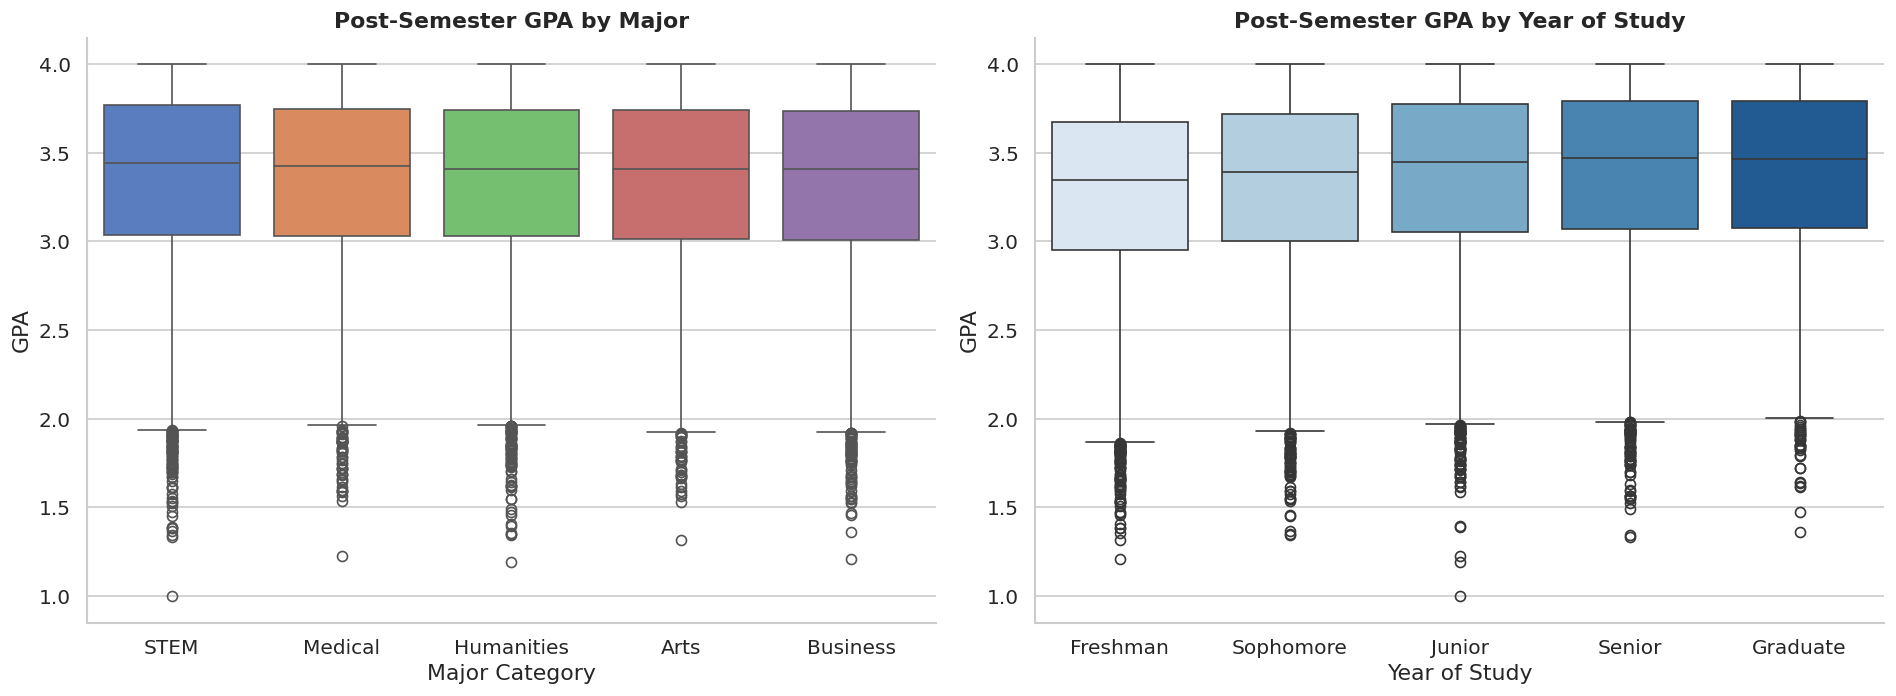

In [15]:
# GPA by Major Category and Year of Study
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# By Major
sns.boxplot(data=df, x="Major_Category", y="Post_Semester_GPA",
            order=df.groupby("Major_Category")["Post_Semester_GPA"].median().sort_values(ascending=False).index,
            palette="muted", ax=axes[0])
axes[0].set_title("Post-Semester GPA by Major", fontweight="bold")
axes[0].set_xlabel("Major Category")
axes[0].set_ylabel("GPA")

# By Year of Study
year_order = ["Freshman", "Sophomore", "Junior", "Senior", "Graduate"]
sns.boxplot(data=df, x="Year_of_Study", y="Post_Semester_GPA",
            order=year_order, palette="Blues", ax=axes[1])
axes[1].set_title("Post-Semester GPA by Year of Study", fontweight="bold")
axes[1].set_xlabel("Year of Study")
axes[1].set_ylabel("GPA")

plt.tight_layout()
save("07_gpa_by_groups.png")

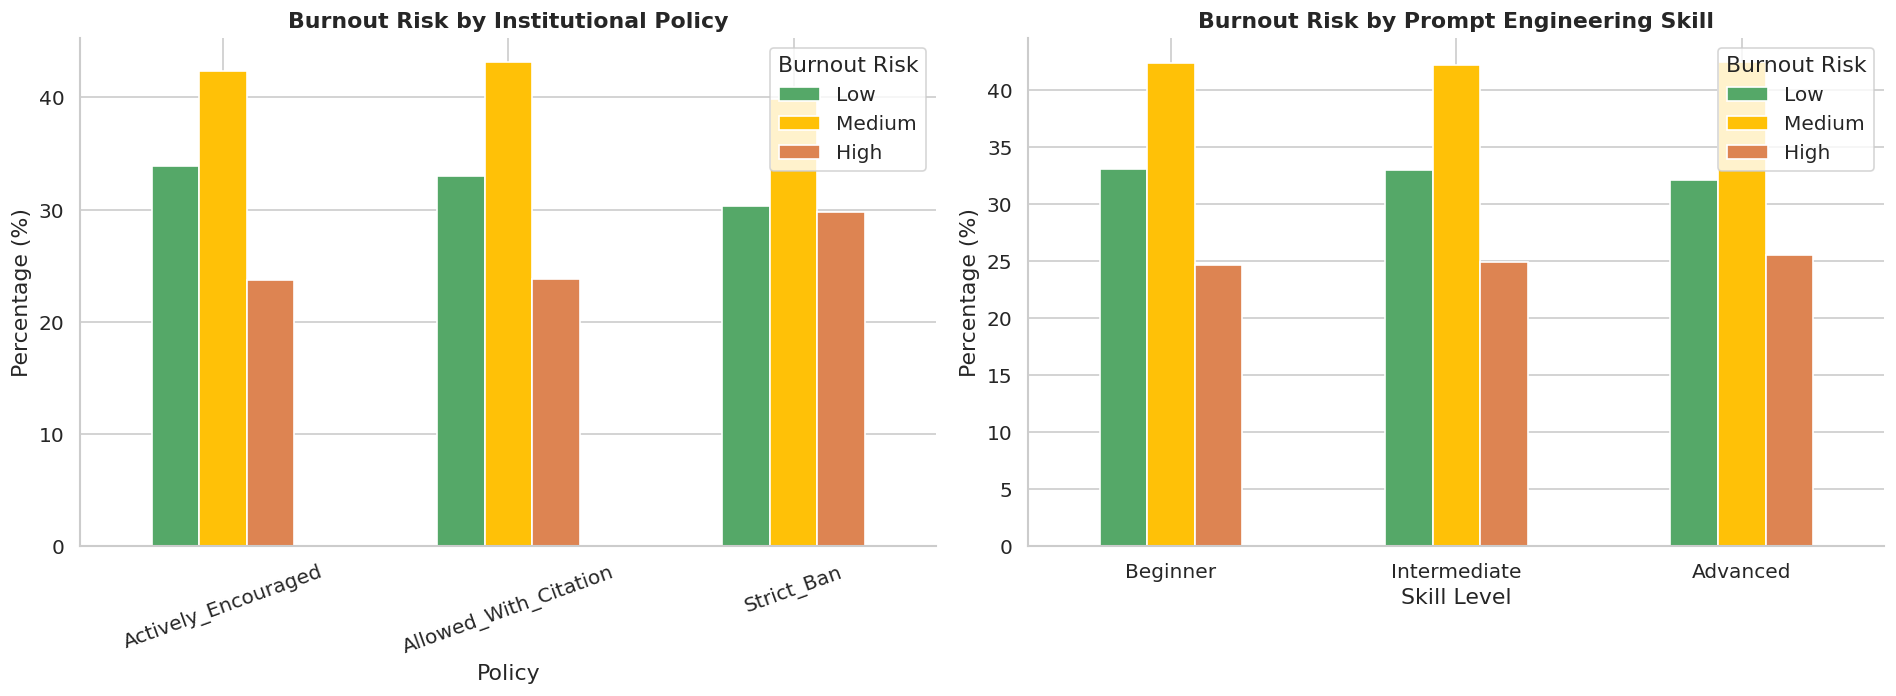

In [16]:
# Burnout by Institutional Policy and Prompt Skill
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
order_burnout = ["Low", "Medium", "High"]

# By Institutional Policy
policy_burnout = df.groupby(["Institutional_Policy", "Burnout_Risk_Level"]).size().unstack(fill_value=0)
policy_burnout = policy_burnout[order_burnout]
policy_burnout_pct = policy_burnout.div(policy_burnout.sum(axis=1), axis=0) * 100
policy_burnout_pct.plot(kind="bar", ax=axes[0], color=["#55A868", "#FFC107", "#DD8452"],
                         edgecolor="white", stacked=False)
axes[0].set_title("Burnout Risk by Institutional Policy", fontweight="bold")
axes[0].set_xlabel("Policy")
axes[0].set_ylabel("Percentage (%)")
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend(title="Burnout Risk")

# By Prompt Engineering Skill
skill_order = ["Beginner", "Intermediate", "Advanced"]
skill_burnout = df.groupby(["Prompt_Engineering_Skill", "Burnout_Risk_Level"]).size().unstack(fill_value=0)
skill_burnout = skill_burnout.reindex(skill_order)[order_burnout]
skill_burnout_pct = skill_burnout.div(skill_burnout.sum(axis=1), axis=0) * 100
skill_burnout_pct.plot(kind="bar", ax=axes[1], color=["#55A868", "#FFC107", "#DD8452"],
                        edgecolor="white")
axes[1].set_title("Burnout Risk by Prompt Engineering Skill", fontweight="bold")
axes[1].set_xlabel("Skill Level")
axes[1].set_ylabel("Percentage (%)")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Burnout Risk")

plt.tight_layout()
save("08_burnout_by_groups.png")

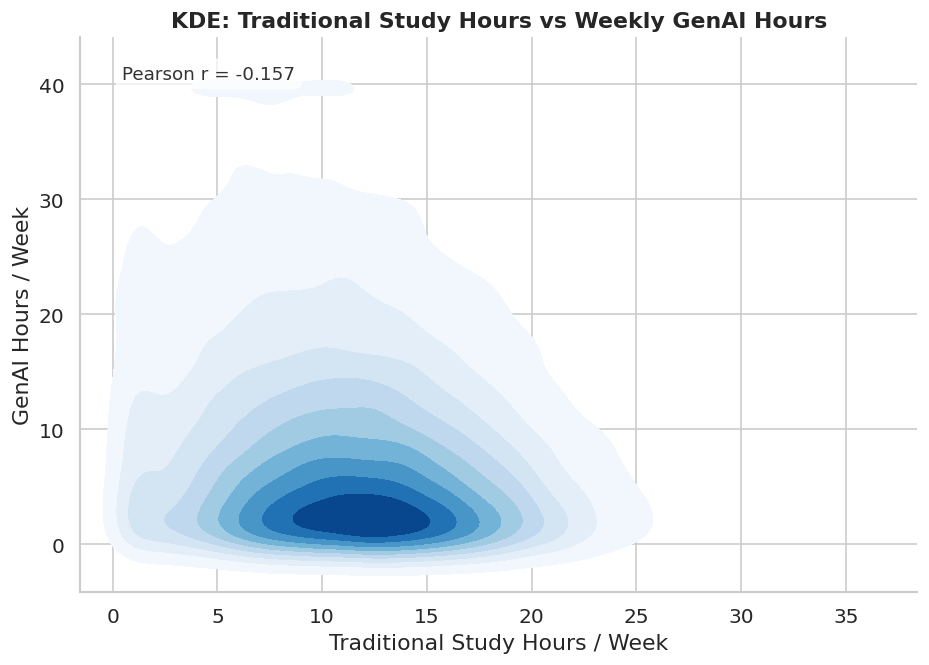

In [17]:
# Traditional Study Hours vs GenAI hours
fig, ax = plt.subplots(figsize=(9, 6))
sns.kdeplot(data=df, x="Traditional_Study_Hours", y="Weekly_GenAI_Hours",
            fill=True, cmap="Blues", thresh=0.05, ax=ax)
ax.set_title("KDE: Traditional Study Hours vs Weekly GenAI Hours", fontweight="bold")
ax.set_xlabel("Traditional Study Hours / Week")
ax.set_ylabel("GenAI Hours / Week")
corr_val = df[["Traditional_Study_Hours", "Weekly_GenAI_Hours"]].corr().iloc[0, 1]
ax.text(0.05, 0.95, f"Pearson r = {corr_val:.3f}", transform=ax.transAxes,
        va="top", fontsize=11, color="#333333",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))
save("09_study_kde.png")

## 10. Outlier Detection

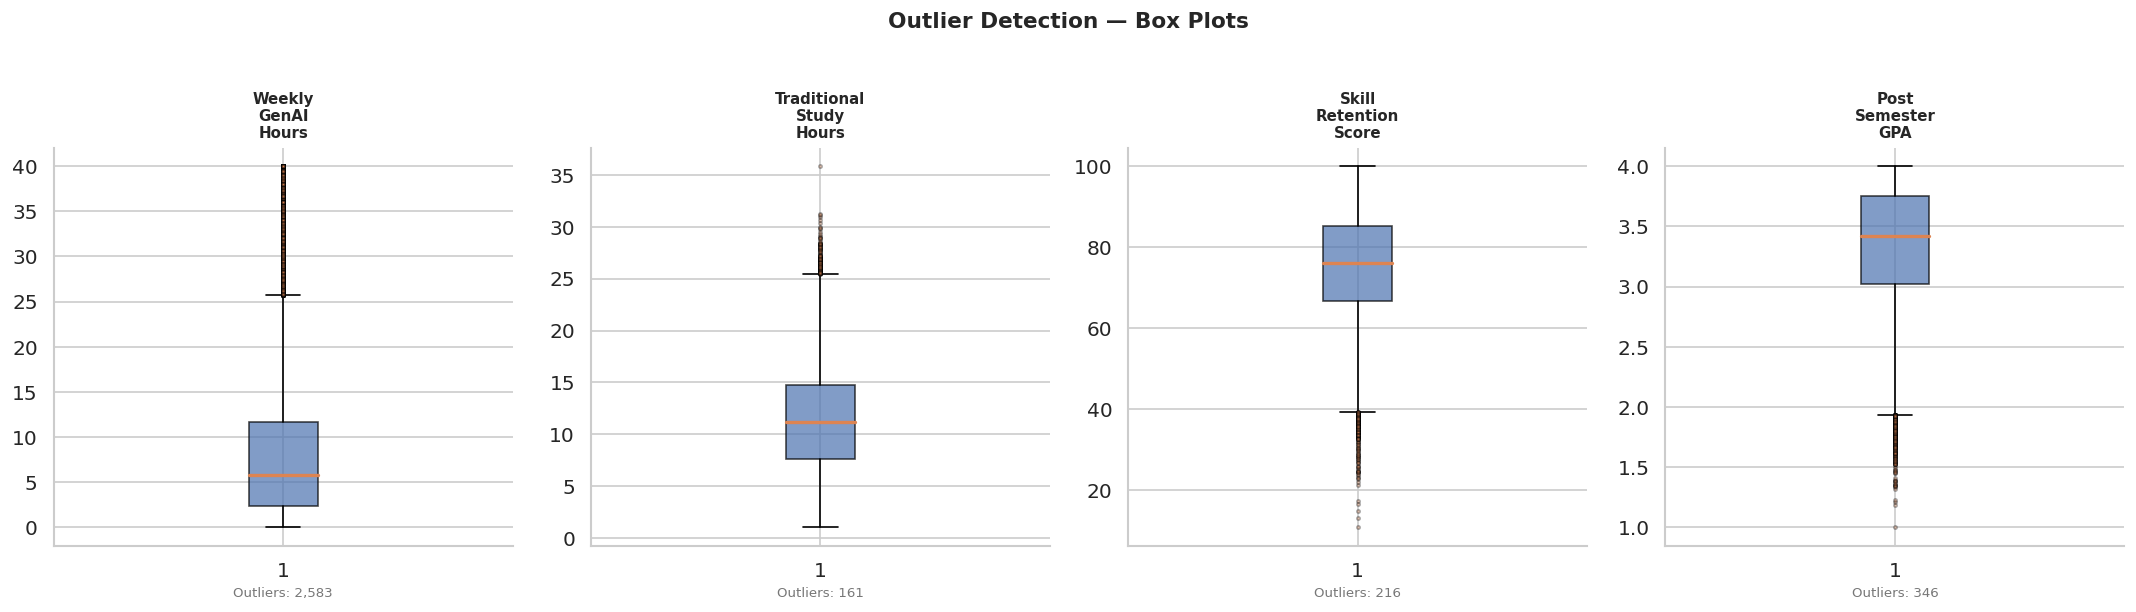

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
outlier_cols = ["Weekly_GenAI_Hours", "Traditional_Study_Hours",
                "Skill_Retention_Score", "Post_Semester_GPA"]

for ax, col in zip(axes, outlier_cols):
    ax.boxplot(df[col], vert=True, patch_artist=True,
               boxprops=dict(facecolor="#4C72B0", alpha=0.7),
               medianprops=dict(color="#DD8452", lw=2),
               flierprops=dict(marker="o", markerfacecolor="#DD8452", markersize=2, alpha=0.3))
    ax.set_title(col.replace("_", "\n"), fontsize=9, fontweight="bold")
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    outliers = ((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum()
    ax.set_xlabel(f"Outliers: {outliers:,}", fontsize=8, color="#777777")

plt.suptitle("Outlier Detection — Box Plots", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
save("10_outlier_boxplots.png")

In [19]:
# IQR outlier summary
print("IQR-based outlier count per numerical column:\n")
for col in num_df.columns:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = ((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum()
    pct = n_out / len(df) * 100
    print(f"  {col:<35} {n_out:>5,} outliers ({pct:.2f}%)")

IQR-based outlier count per numerical column:

  Pre_Semester_GPA                      328 outliers (0.66%)
  Weekly_GenAI_Hours                  2,583 outliers (5.17%)
  Tool_Diversity                          0 outliers (0.00%)
  Traditional_Study_Hours               161 outliers (0.32%)
  Perceived_AI_Dependency               190 outliers (0.38%)
  Anxiety_Level_During_Exams              0 outliers (0.00%)
  Post_Semester_GPA                     346 outliers (0.69%)
  Skill_Retention_Score                 216 outliers (0.43%)


## 11. Key Insights 🔍

| # | Finding |
|---|---------|
| 1 | **No missing values** — clean dataset ready for modelling without imputation. |
| 2 | **GPA is roughly symmetric** (skew ≈ 0) between 2.0–4.0, with mean ≈ 3.28. |
| 3 | **Burnout Risk** is balanced across Low / Medium / High (~33% each). |
| 4 | **GenAI usage and traditional study hours are weakly negatively correlated** — students using AI more tend to study traditionally less. |
| 5 | **Pre-GPA is the strongest predictor of Post-GPA** (high positive correlation), as expected. |
| 6 | **Advanced prompt engineering skill** is associated with lower burnout rates. |
| 7 | **Strict Ban policy** institutions show a different burnout profile vs Allowed/Encouraged. |
| 8 | **Tool Diversity and Paid Subscription** have low correlations with GPA — suggests quality of use matters more than breadth. |
| 9 | Outliers in `Weekly_GenAI_Hours` and `Traditional_Study_Hours` are real (heavy users), not noise — keep them. |
| 10 | Medical students show marginally higher GPAs; Humanities students show wider variance. |

---
### Next Step → `02_feature_engineering.ipynb`
